Processing manual filter... (This may take a moment)


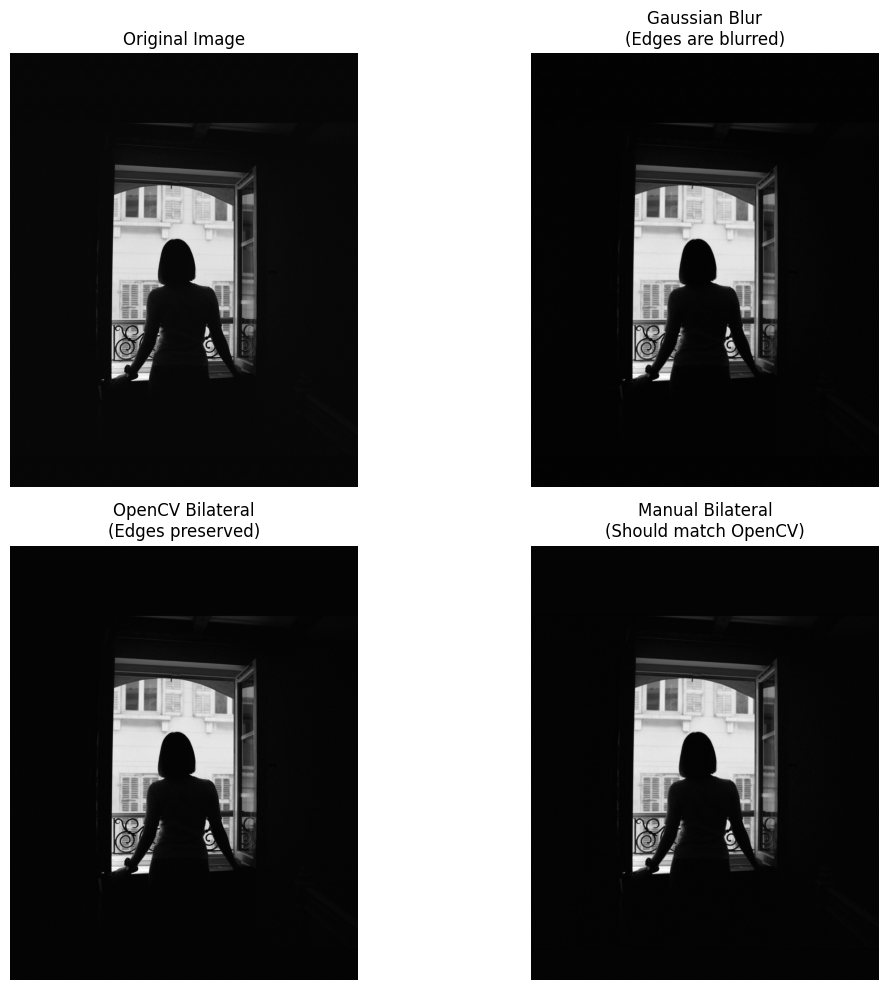

Average Difference between Manual and OpenCV: 0.5985


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def bilateral_filter_manual(image, d, sigma_s, sigma_r):

    # Get image dimensions
    h, w = image.shape

    # Create the output image
    output = np.zeros((h, w), dtype=np.float32)

    # Pad the image to handle borders
    radius = d // 2
    padded_image = cv2.copyMakeBorder(image, radius, radius, radius, radius, cv2.BORDER_REFLECT)

    # Pre-compute the spatial Gaussian kernel (it's constant for the whole image)
    # Distance from center (0,0) to (x,y)
    y_coords, x_coords = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_kernel = np.exp(-(x_coords**2 + y_coords**2) / (2 * sigma_s**2))

    # Loop over every pixel in the image (This is slow in Python, but correct for "manual")
    print("Processing manual filter... (This may take a moment)")
    for i in range(h):
        for j in range(w):

            center_val = padded_image[i + radius, j + radius]
            neighborhood = padded_image[i:i+d, j:j+d]

            intensity_diff = neighborhood - center_val
            range_kernel = np.exp(-(intensity_diff**2) / (2 * sigma_r**2))

            combined_weights = spatial_kernel * range_kernel

            norm_factor = np.sum(combined_weights)
            result = np.sum(combined_weights * neighborhood) / norm_factor

            output[i, j] = result

    return output.astype(np.uint8)

# --- Main Execution ---

# 1. Load Image (Grayscale)
# UPDATED PATH BELOW:
img = cv2.imread(r'D:\computer_Vision_Inclass_11_26\looking_out.jpg', 0)

if img is None:
    print("Image not found. Check path D:\\computer_Vision_Inclass_11_26\\looking_out.jpg")
    exit()

# Parameters
d = 9
sigma_s = 75
sigma_r = 75

# 10(b) Apply Gaussian Smoothing (OpenCV)
gaussian = cv2.GaussianBlur(img, (d, d), sigma_s)

# 10(c) Apply Bilateral Filter (OpenCV)
bilateral_cv = cv2.bilateralFilter(img, d, sigma_r, sigma_s)

# 10(d) Apply Bilateral Filter (Manual)
bilateral_manual = bilateral_filter_manual(img, d, sigma_s, sigma_r)

# --- Visualization & Comparison ---
plt.figure(figsize=(12, 10))

# Original
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

# Gaussian Blur
plt.subplot(2, 2, 2)
plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian Blur\n(Edges are blurred)")
plt.axis('off')

# OpenCV Bilateral
plt.subplot(2, 2, 3)
plt.imshow(bilateral_cv, cmap='gray')
plt.title("OpenCV Bilateral\n(Edges preserved)")
plt.axis('off')

# Manual Bilateral
plt.subplot(2, 2, 4)
plt.imshow(bilateral_manual, cmap='gray')
plt.title("Manual Bilateral\n(Should match OpenCV)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Verification: Calculate difference
diff = np.abs(bilateral_cv.astype(float) - bilateral_manual.astype(float))
print(f"Average Difference between Manual and OpenCV: {np.mean(diff):.4f}")